
Module A1 - Static Noise Test


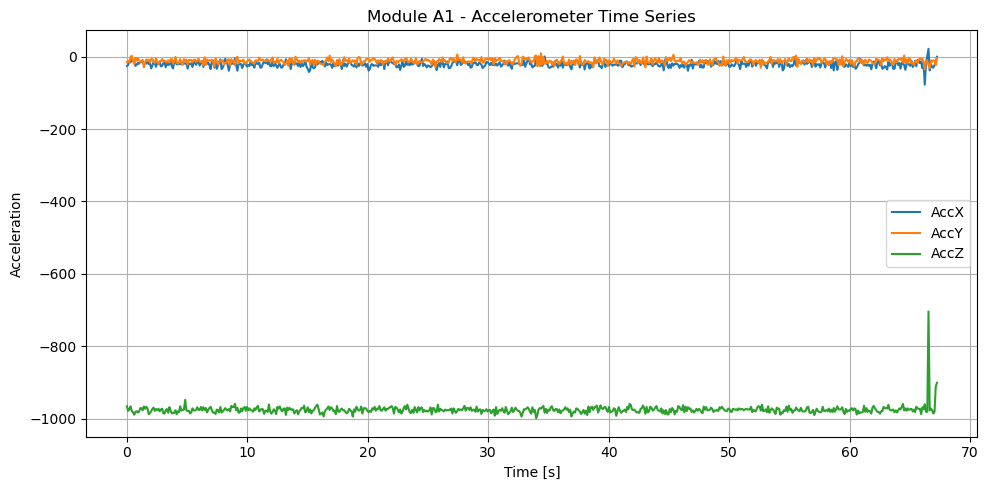

Sample rate [Hz]: 9.999999999999858
Means:
  AccX: -21.088323
  AccY: -12.656931
  AccZ: -975.139536
Measured noise RMS:
  AccX: 7.495380
  AccY: 6.630583
  AccZ: 12.911749
Predicted datasheet RMS (approx): 2.631400e-03


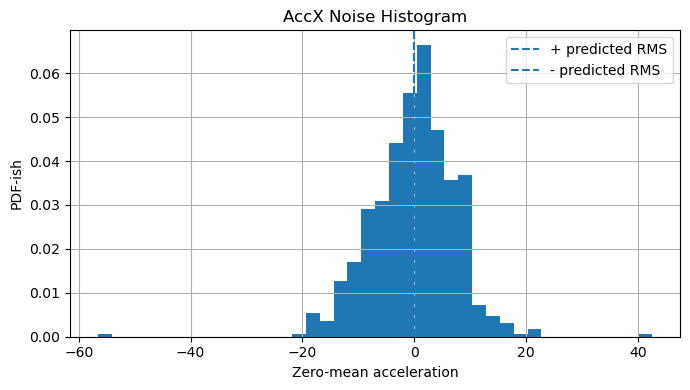

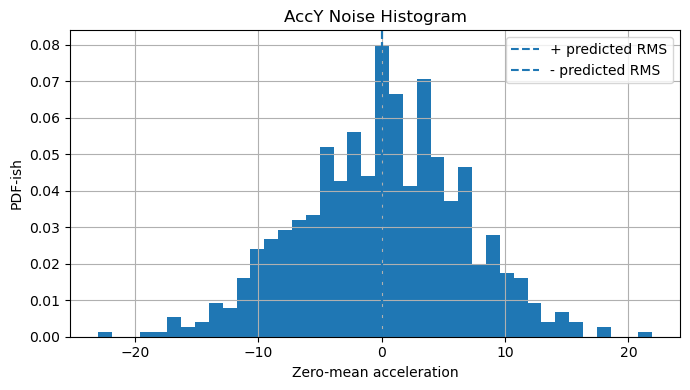

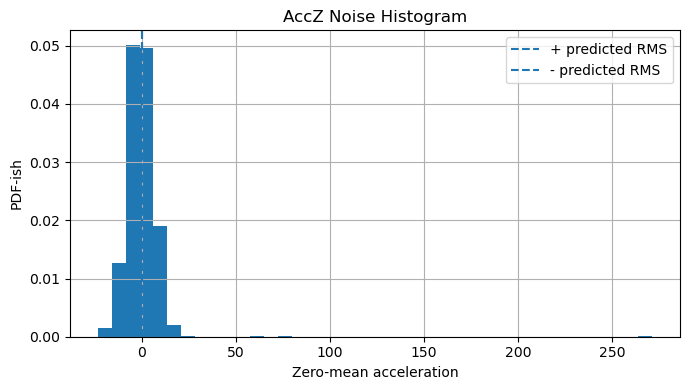

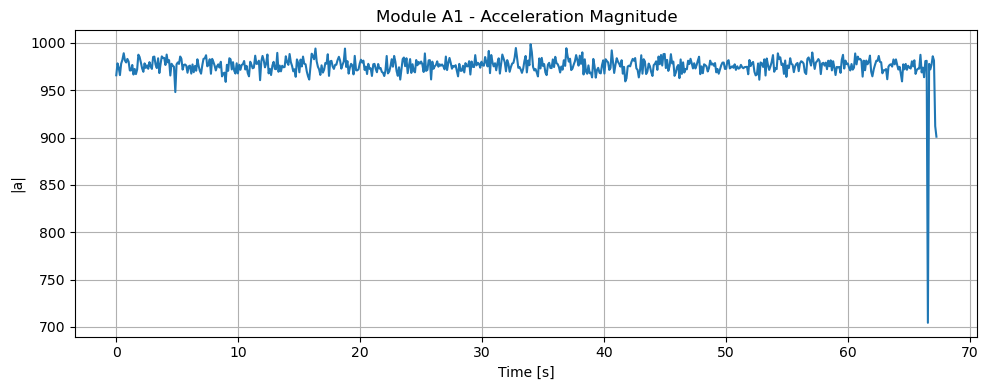


Module A2 - Six-Face Calibration


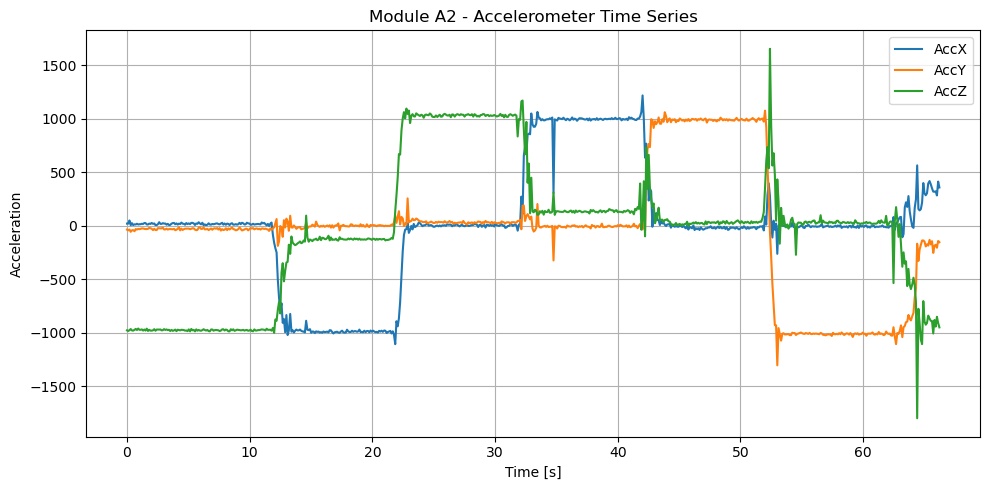

  label        AccX        AccY        AccZ
0    +X   17.493119  -30.972018 -974.026972
1    -X -858.532294   -5.488440 -257.422936
2    +Y    8.569174   40.952752  986.996055
3    -Y  867.528073  126.388532  149.185872
4    +Z   -6.105688  540.832385   88.343211
5    -Z   63.226018 -852.776814 -194.940708
Bias X, scale X: -420.519587, 44.664866
Bias Y, scale Y: 83.670642, -4.356012
Bias Z, scale Z: -53.298748, 14.443460


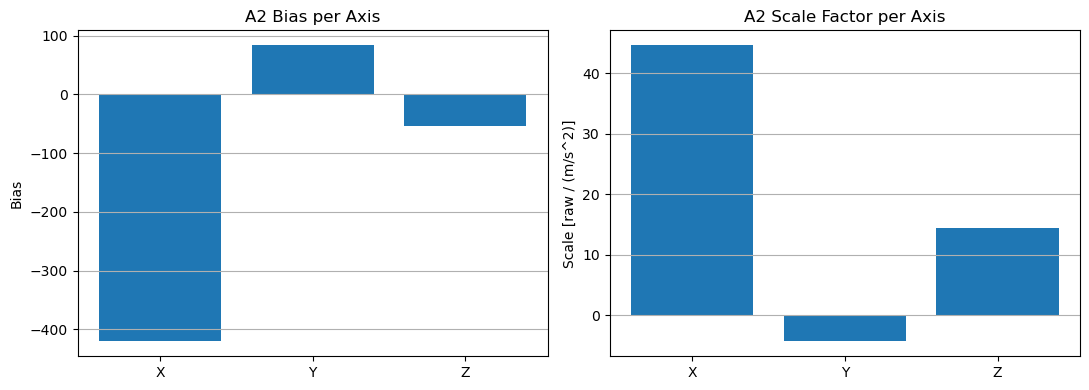

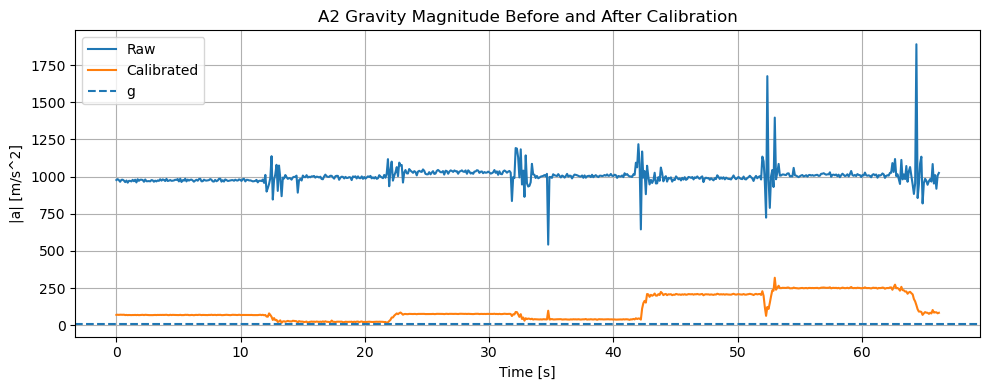


Module B1 - Zero-Rate Bias Test


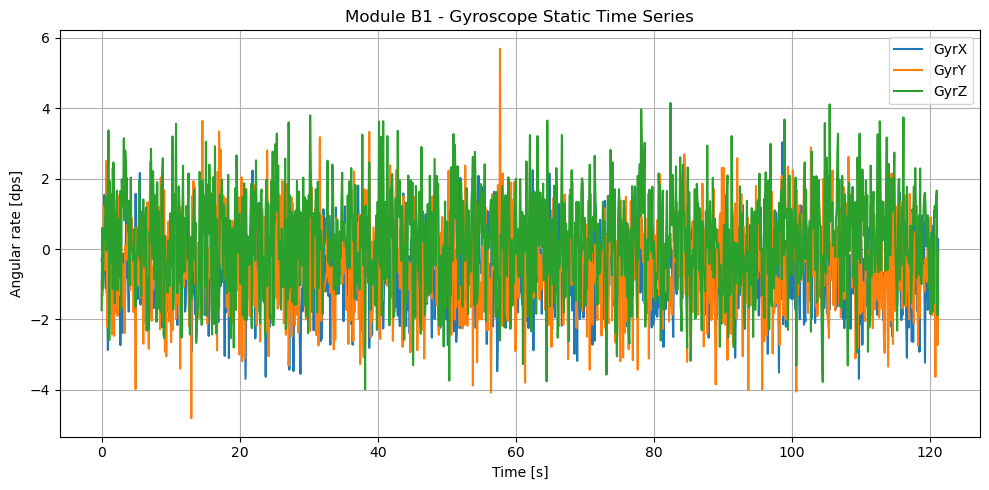

ZRO bias [dps]:
  GyrX: -0.646827 dps   (38.810 deg/min)
  GyrY: -0.441204 dps   (26.472 deg/min)
  GyrZ: 0.252334 dps   (15.140 deg/min)
Integrated drift over record [deg]:
  Raw X, Y, Z: -77.876, -53.018, 30.470
  Corr X, Y, Z: -0.062, 0.059, 0.114


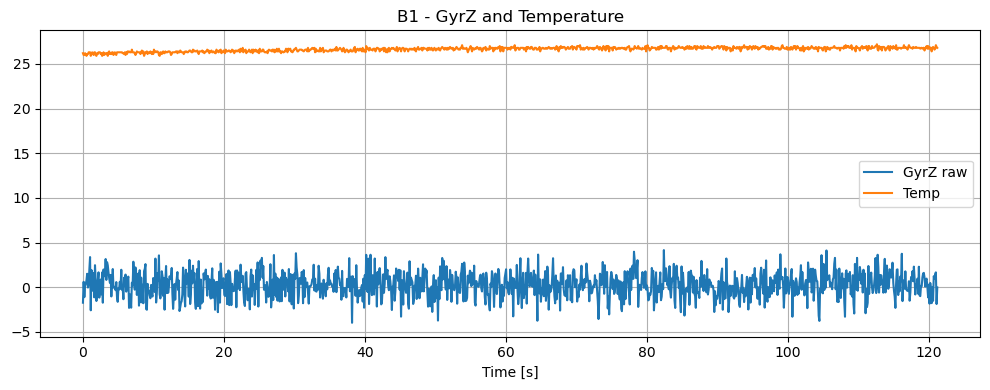

Corr(Temp, GyrZ): -0.0029
d(GyrZ)/dTemp: -0.017050 dps/degC
Predicted gyro RMS from noise density [dps]: 0.033541

Module B2 - Known Rotation Test


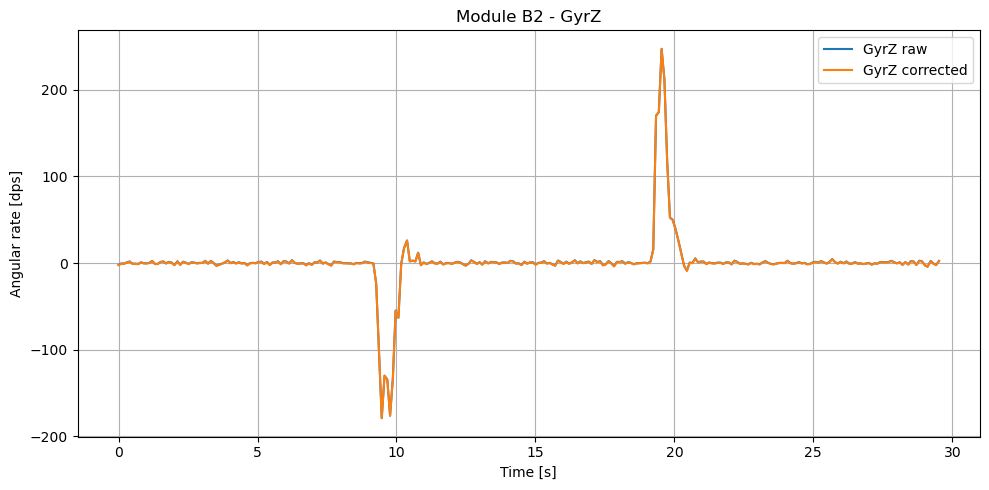

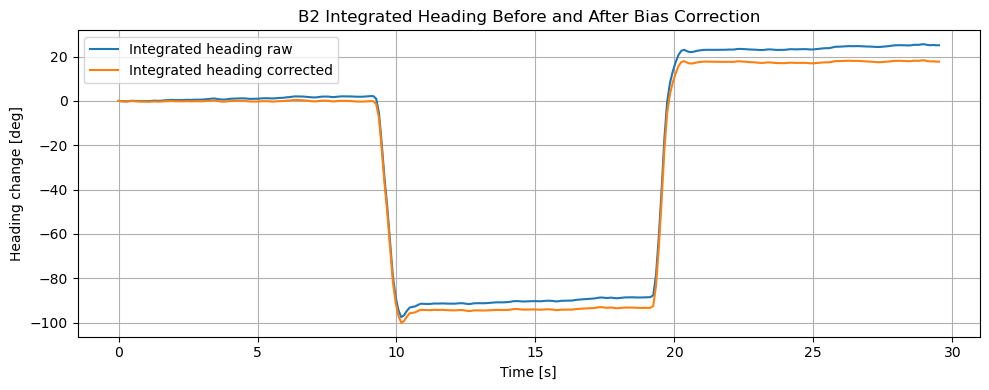

Detected turn segments (row indices): [(92, 100), (103, 103), (192, 200)]
   segment   i0   i1     t0     t1  angle_raw_deg  angle_cor_deg  \
0        1   92  100   9.27  10.07       -95.2400     -95.441867   
1        2  103  103  10.38  10.38         0.0000       0.000000   
2        3  192  200  19.34  20.15        99.0695      98.867633   

   abs_error_raw_deg  abs_error_cor_deg  
0             5.2400           5.441867  
1            90.0000          90.000000  
2             9.0695           8.867633  

Module C1 - Raw Field Measurement


C:\Users\msgok\AppData\Local\Temp\ipykernel_32544\3345785696.py:467: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  angle_raw = np.trapz(gz[i0:i1+1], dx=dt)
C:\Users\msgok\AppData\Local\Temp\ipykernel_32544\3345785696.py:468: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  angle_cor = np.trapz(gz_corr[i0:i1+1], dx=dt)


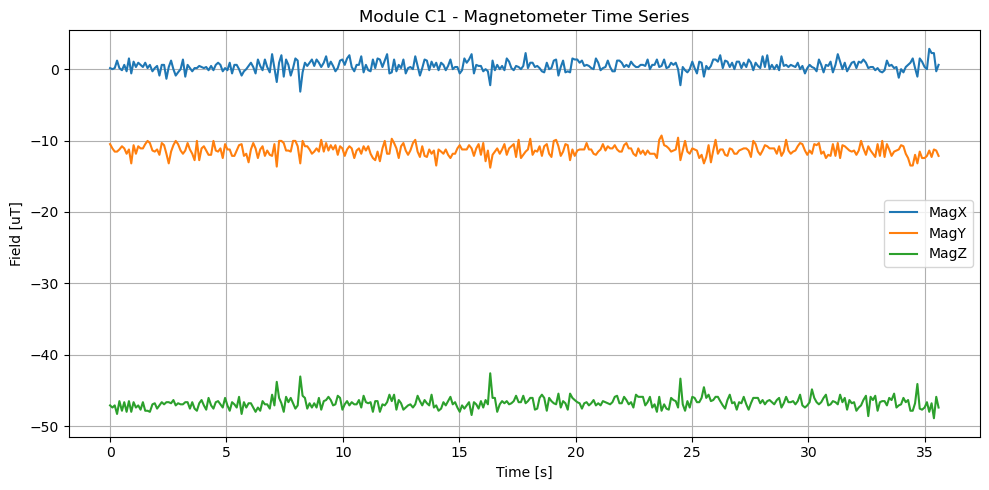

Mean |B| [uT]: 48.119
Std |B| [uT]: 0.734
Difference from ~47 uT [uT]: 1.119
Raw heading mean [deg]: -87.731
Approx true-north heading estimate [deg]: -76.731


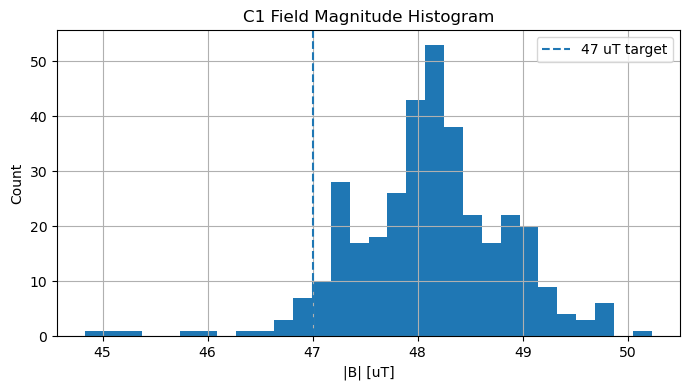


Module C2 - Hard-Iron / Soft-Iron Calibration


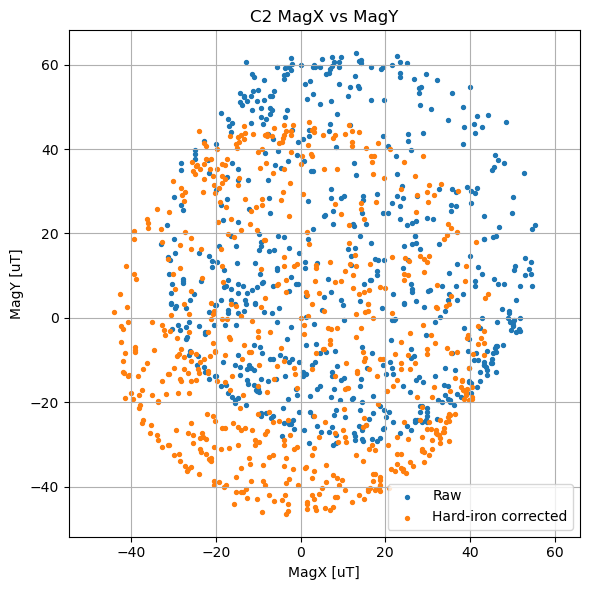

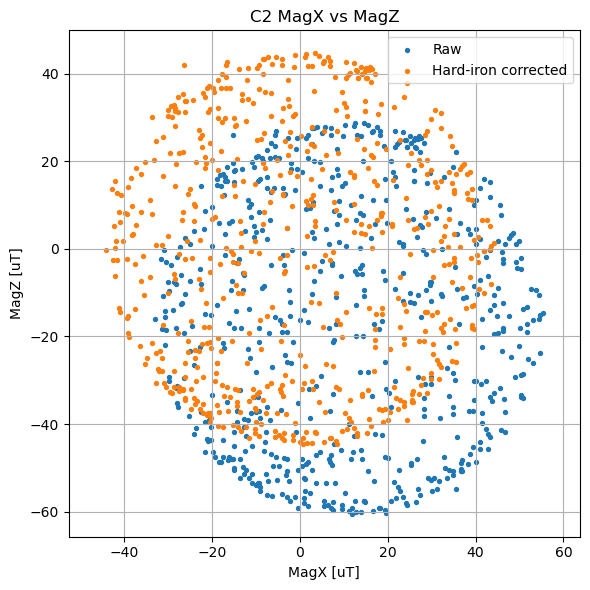

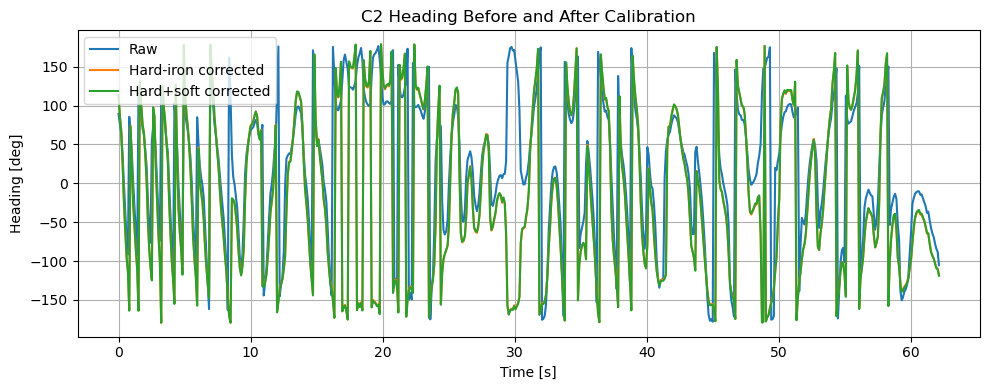

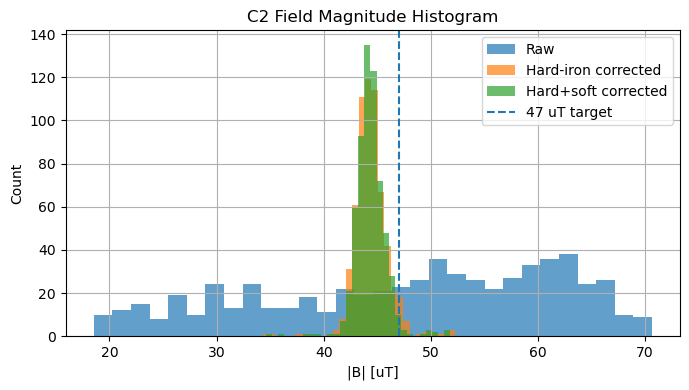

Hard-iron offsets [uT]:
  ox, oy, oz = 11.175, 16.275, -15.825
Soft-iron scale factors:
  sx, sy, sz = 1.020, 0.971, 1.010
Mean |B| raw [uT]: 47.823
Mean |B| hard-iron corrected [uT]: 44.409
Mean |B| hard+soft corrected [uT]: 44.360

Module D - Pendulum Test
Chosen oscillating axis: AccY


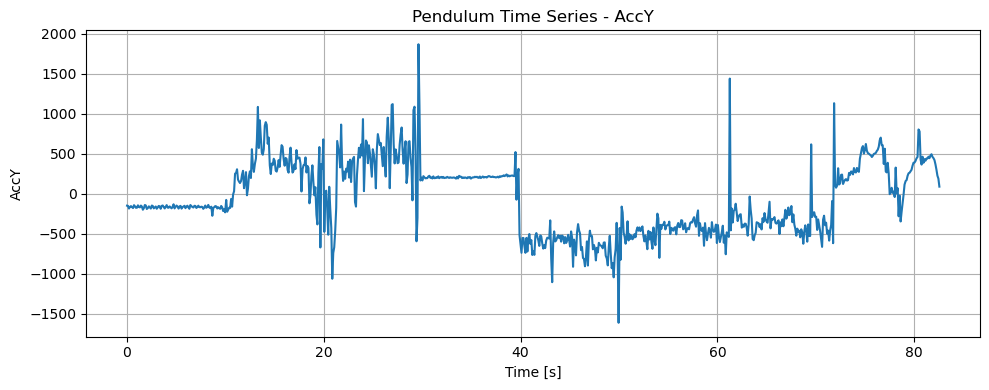

Measured period from peaks [s]: 0.5831
Theoretical period [s]: 1.0990
Percent error [%]: -46.94


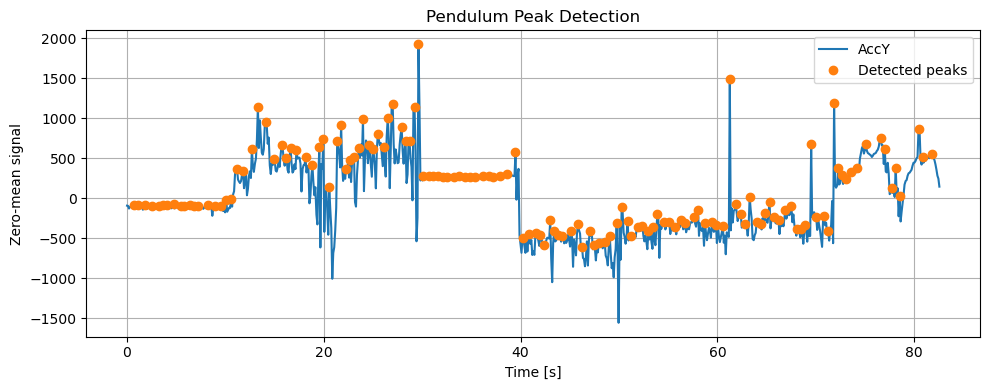

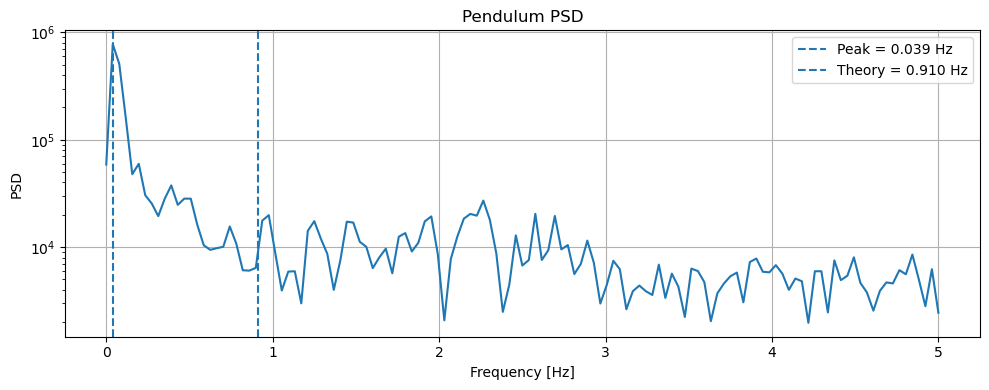

Peak PSD frequency [Hz]: 0.0391
PSD-implied period [s]: 25.6000
Theoretical frequency [Hz]: 0.9100


,Module,Metric,Value
0,A1,Predicted acc RMS,0.002631
1,B1,GyrX bias [dps],-0.646827
2,B1,GyrY bias [dps],-0.441204
3,B1,GyrZ bias [dps],0.252334
4,C1,Mean |B| [uT],48.118917
5,D,Measured period [s],0.583094
6,D,Theoretical period [s],1.098956


In [2]:
# %% [markdown]
# # OLA IMU Analysis Notebook
# #
# # This notebook loads CSV files for:
# #   Module A - Accelerometer
# #   Module B - Gyroscope
# #   Module C - Magnetometer
# #   Module D - Pendulum
# #
# # It creates the required plots and computes the main quantitative results.

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks, welch

# %%
# ---------------- USER SETTINGS ----------------
# Put your CSV filenames here.
# Update these names to match your actual files.

FILES = {
    "A1": "A1.StaticNoise.csv",
    "A2": "A2.GravityVectorCheck.csv",
    "B1": "B1.ZeroRateBiasTest.csv",
    "B2": "B2.KnownRotationTest.csv",
    "C1": "C1.RawFieldMeasurement.csv",
    "C2": "C2.HardSoftIron.csv",
    "D" : "D.163degPendulum.csv",
}

# nominal sample rate if timestamps are only formatted to nearest second
FS_DEFAULT = 10.0
DT_DEFAULT = 1.0 / FS_DEFAULT
G = 9.80665                      # m/s^2
SAN_DIEGO_B_UT = 47.0            # target total magnetic field magnitude in uT
MAG_DECLINATION_DEG = 11.0       # approx east declination in San Diego
ACC_NOISE_DENSITY_UG_SQRT_HZ = 120.0   # replace if your datasheet gives another value
GYR_NOISE_DENSITY_DPS_SQRT_HZ = 0.015  # dps/sqrt(Hz) from assignment prompt
PENDULUM_LENGTH_M = 0.30         # replace with your measured pendulum length

# face labels for A2; update if your sequence differs
A2_FACE_LABELS = ["+X", "-X", "+Y", "-Y", "+Z", "-Z"]

# threshold to find the moving parts of the B2 rotation
B2_GYRZ_TURN_THRESHOLD_DPS = 20.0

# pendulum peak spacing guess
D_MIN_PEAK_DISTANCE_SEC = 0.5

# %%
# ---------------- BASIC HELPERS ----------------

def load_csv_clean(path):
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df

def to_numeric_series(s):
    return pd.to_numeric(s, errors="coerce")

def get_time_seconds(df, fs_default=FS_DEFAULT):
    if "Timestamp" not in df.columns:
        return np.arange(len(df)) / fs_default

    t_raw = pd.to_datetime(df["Timestamp"], errors="coerce")
    if t_raw.notna().sum() >= 2:
        t_sec = (t_raw - t_raw.iloc[0]).dt.total_seconds().to_numpy()

        # if timestamps collapse to repeated whole seconds, fall back to uniform sample rate
        dt = np.diff(t_sec)
        if np.nanmedian(dt) == 0 or np.sum(dt > 0) < max(3, 0.1 * len(dt)):
            return np.arange(len(df)) / fs_default
        return t_sec

    return np.arange(len(df)) / fs_default

def estimate_fs(t):
    dt = np.diff(t)
    dt = dt[np.isfinite(dt)]
    dt = dt[dt > 0]
    if len(dt) == 0:
        return FS_DEFAULT
    return 1.0 / np.median(dt)

def column_or_none(df, name):
    return name if name in df.columns else None

def mag3(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)

def rms(x):
    x = np.asarray(x, dtype=float)
    return np.sqrt(np.nanmean(x**2))

def centered_rms(x):
    x = np.asarray(x, dtype=float)
    return np.sqrt(np.nanmean((x - np.nanmean(x))**2))

def print_header(title):
    print("\n" + "="*80)
    print(title)
    print("="*80)

# %%
# ---------------- AXIS ACCESSORS ----------------

def get_acc_cols(df):
    return {
        "x": column_or_none(df, "AccX"),
        "y": column_or_none(df, "AccY"),
        "z": column_or_none(df, "AccZ"),
    }

def get_gyr_cols(df):
    return {
        "x": column_or_none(df, "GyrX"),
        "y": column_or_none(df, "GyrY"),
        "z": column_or_none(df, "GyrZ"),
    }

def get_mag_cols(df):
    return {
        "x": column_or_none(df, "MagX"),
        "y": column_or_none(df, "MagY"),
        "z": column_or_none(df, "MagZ"),
    }

def get_temp_col(df):
    return column_or_none(df, "Temp")

# %%
# ---------------- PLOTTING HELPERS ----------------

def plot_timeseries(t, data_dict, title, ylabel):
    plt.figure(figsize=(10, 5))
    for label, y in data_dict.items():
        if y is not None:
            plt.plot(t, y, label=label)
    plt.xlabel("Time [s]")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def trapezoid_integrate(y, dt):
    y = np.asarray(y, dtype=float)
    out = np.zeros_like(y)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5 * (y[i-1] + y[i]) * dt
    return out

# %%
# ---------------- MODULE A1 ----------------

def analyze_A1(path):
    print_header("Module A1 - Static Noise Test")
    df = load_csv_clean(path)
    t = get_time_seconds(df)
    fs = estimate_fs(t)
    acc = get_acc_cols(df)

    ax = to_numeric_series(df[acc["x"]]).to_numpy()
    ay = to_numeric_series(df[acc["y"]]).to_numpy()
    az = to_numeric_series(df[acc["z"]]).to_numpy()

    plot_timeseries(
        t,
        {"AccX": ax, "AccY": ay, "AccZ": az},
        "Module A1 - Accelerometer Time Series",
        "Acceleration"
    )

    means = {"AccX": np.nanmean(ax), "AccY": np.nanmean(ay), "AccZ": np.nanmean(az)}
    rms_meas = {
        "AccX": centered_rms(ax),
        "AccY": centered_rms(ay),
        "AccZ": centered_rms(az),
    }

    # convert datasheet density from ug/sqrt(Hz) to m/s^2/sqrt(Hz)
    acc_nd_si = ACC_NOISE_DENSITY_UG_SQRT_HZ * 1e-6 * G
    # approximate RMS over Nyquist BW
    rms_pred = acc_nd_si * np.sqrt(fs / 2.0)

    print("Sample rate [Hz]:", fs)
    print("Means:")
    for k, v in means.items():
        print(f"  {k}: {v:.6f}")
    print("Measured noise RMS:")
    for k, v in rms_meas.items():
        print(f"  {k}: {v:.6f}")
    print(f"Predicted datasheet RMS (approx): {rms_pred:.6e}")

    for label, y in zip(["AccX", "AccY", "AccZ"], [ax, ay, az]):
        plt.figure(figsize=(7, 4))
        plt.hist(y - np.nanmean(y), bins=40, density=True)
        plt.axvline(rms_pred, linestyle="--", label="+ predicted RMS")
        plt.axvline(-rms_pred, linestyle="--", label="- predicted RMS")
        plt.title(f"{label} Noise Histogram")
        plt.xlabel("Zero-mean acceleration")
        plt.ylabel("PDF-ish")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    amag = mag3(ax, ay, az)
    plt.figure(figsize=(10, 4))
    plt.plot(t, amag)
    plt.xlabel("Time [s]")
    plt.ylabel("|a|")
    plt.title("Module A1 - Acceleration Magnitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        "df": df,
        "t": t,
        "fs": fs,
        "means": means,
        "rms_meas": rms_meas,
        "rms_pred": rms_pred,
    }

# %%
# ---------------- MODULE A2 ----------------

def analyze_A2(path, face_labels=A2_FACE_LABELS):
    print_header("Module A2 - Six-Face Calibration")
    df = load_csv_clean(path)
    t = get_time_seconds(df)
    acc = get_acc_cols(df)

    ax = to_numeric_series(df[acc["x"]]).to_numpy()
    ay = to_numeric_series(df[acc["y"]]).to_numpy()
    az = to_numeric_series(df[acc["z"]]).to_numpy()

    plot_timeseries(
        t,
        {"AccX": ax, "AccY": ay, "AccZ": az},
        "Module A2 - Accelerometer Time Series",
        "Acceleration"
    )

    n = len(df)
    nfaces = 6
    seg_len = n // nfaces
    if seg_len < 5:
        raise ValueError("A2 file too short to split into 6 segments.")

    seg_means = []
    for i in range(nfaces):
        i0 = i * seg_len
        i1 = (i + 1) * seg_len if i < nfaces - 1 else n
        seg_means.append({
            "label": face_labels[i] if i < len(face_labels) else f"face{i+1}",
            "AccX": np.nanmean(ax[i0:i1]),
            "AccY": np.nanmean(ay[i0:i1]),
            "AccZ": np.nanmean(az[i0:i1]),
        })

    seg_df = pd.DataFrame(seg_means)
    print(seg_df)

    # Solve per-axis bias and scale using paired +/- faces
    # assumed label order: +X, -X, +Y, -Y, +Z, -Z
    def solve_bias_scale(pos_val, neg_val):
        # raw_pos = b + s*(+g), raw_neg = b + s*(-g)
        b = 0.5 * (pos_val + neg_val)
        s = 0.5 * (pos_val - neg_val) / G
        return b, s

    bx, sx = solve_bias_scale(seg_df.loc[0, "AccX"], seg_df.loc[1, "AccX"])
    by, sy = solve_bias_scale(seg_df.loc[2, "AccY"], seg_df.loc[3, "AccY"])
    bz, sz = solve_bias_scale(seg_df.loc[4, "AccZ"], seg_df.loc[5, "AccZ"])

    print(f"Bias X, scale X: {bx:.6f}, {sx:.6f}")
    print(f"Bias Y, scale Y: {by:.6f}, {sy:.6f}")
    print(f"Bias Z, scale Z: {bz:.6f}, {sz:.6f}")

    ax_cal = (ax - bx) / sx
    ay_cal = (ay - by) / sy
    az_cal = (az - bz) / sz

    amag_raw = mag3(ax, ay, az)
    amag_cal = mag3(ax_cal, ay_cal, az_cal)

    # bar chart of per-axis bias and scale
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(["X", "Y", "Z"], [bx, by, bz])
    axes[0].set_title("A2 Bias per Axis")
    axes[0].set_ylabel("Bias")
    axes[0].grid(True, axis="y")

    axes[1].bar(["X", "Y", "Z"], [sx, sy, sz])
    axes[1].set_title("A2 Scale Factor per Axis")
    axes[1].set_ylabel("Scale [raw / (m/s^2)]")
    axes[1].grid(True, axis="y")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t, amag_raw, label="Raw")
    plt.plot(t, amag_cal, label="Calibrated")
    plt.axhline(G, linestyle="--", label="g")
    plt.xlabel("Time [s]")
    plt.ylabel("|a| [m/s^2]")
    plt.title("A2 Gravity Magnitude Before and After Calibration")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "df": df,
        "seg_df": seg_df,
        "bias": {"x": bx, "y": by, "z": bz},
        "scale": {"x": sx, "y": sy, "z": sz},
        "amag_raw_mean": np.nanmean(amag_raw),
        "amag_cal_mean": np.nanmean(amag_cal),
    }

# %%
# ---------------- MODULE B1 ----------------

def analyze_B1(path):
    print_header("Module B1 - Zero-Rate Bias Test")
    df = load_csv_clean(path)
    t = get_time_seconds(df)
    fs = estimate_fs(t)
    dt = 1.0 / fs

    gyr = get_gyr_cols(df)
    temp_col = get_temp_col(df)

    gx = to_numeric_series(df[gyr["x"]]).to_numpy()
    gy = to_numeric_series(df[gyr["y"]]).to_numpy()
    gz = to_numeric_series(df[gyr["z"]]).to_numpy()
    temp = to_numeric_series(df[temp_col]).to_numpy() if temp_col else None

    plot_timeseries(
        t,
        {"GyrX": gx, "GyrY": gy, "GyrZ": gz},
        "Module B1 - Gyroscope Static Time Series",
        "Angular rate [dps]"
    )

    bias = {
        "GyrX": np.nanmean(gx),
        "GyrY": np.nanmean(gy),
        "GyrZ": np.nanmean(gz),
    }

    drift_deg_min = {k: 60.0 * abs(v) for k, v in bias.items()}

    print("ZRO bias [dps]:")
    for k, v in bias.items():
        print(f"  {k}: {v:.6f} dps   ({drift_deg_min[k]:.3f} deg/min)")

    gx_corr = gx - bias["GyrX"]
    gy_corr = gy - bias["GyrY"]
    gz_corr = gz - bias["GyrZ"]

    ang_x_raw = trapezoid_integrate(gx, dt)
    ang_y_raw = trapezoid_integrate(gy, dt)
    ang_z_raw = trapezoid_integrate(gz, dt)

    ang_x_cor = trapezoid_integrate(gx_corr, dt)
    ang_y_cor = trapezoid_integrate(gy_corr, dt)
    ang_z_cor = trapezoid_integrate(gz_corr, dt)

    print("Integrated drift over record [deg]:")
    print(f"  Raw X, Y, Z: {ang_x_raw[-1]:.3f}, {ang_y_raw[-1]:.3f}, {ang_z_raw[-1]:.3f}")
    print(f"  Corr X, Y, Z: {ang_x_cor[-1]:.3f}, {ang_y_cor[-1]:.3f}, {ang_z_cor[-1]:.3f}")

    if temp is not None:
        plt.figure(figsize=(10, 4))
        plt.plot(t, gz, label="GyrZ raw")
        plt.plot(t, temp, label="Temp")
        plt.xlabel("Time [s]")
        plt.title("B1 - GyrZ and Temperature")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        corr_temp_gz = np.corrcoef(temp[np.isfinite(temp) & np.isfinite(gz)],
                                   gz[np.isfinite(temp) & np.isfinite(gz)])[0, 1]
        slope_gz_temp = np.polyfit(temp[np.isfinite(temp) & np.isfinite(gz)],
                                   gz[np.isfinite(temp) & np.isfinite(gz)], 1)[0]
        print(f"Corr(Temp, GyrZ): {corr_temp_gz:.4f}")
        print(f"d(GyrZ)/dTemp: {slope_gz_temp:.6f} dps/degC")

    gyr_rms_pred = GYR_NOISE_DENSITY_DPS_SQRT_HZ * np.sqrt(fs / 2.0)
    print(f"Predicted gyro RMS from noise density [dps]: {gyr_rms_pred:.6f}")

    return {
        "df": df,
        "fs": fs,
        "dt": dt,
        "bias": bias,
        "drift_raw": {"x": ang_x_raw[-1], "y": ang_y_raw[-1], "z": ang_z_raw[-1]},
        "drift_cor": {"x": ang_x_cor[-1], "y": ang_y_cor[-1], "z": ang_z_cor[-1]},
    }

# %%
# ---------------- MODULE B2 ----------------

def analyze_B2(path, z_bias_from_B1=0.0):
    print_header("Module B2 - Known Rotation Test")
    df = load_csv_clean(path)
    t = get_time_seconds(df)
    fs = estimate_fs(t)
    dt = 1.0 / fs

    gyr = get_gyr_cols(df)
    gz = to_numeric_series(df[gyr["z"]]).to_numpy()
    gz_corr = gz - z_bias_from_B1

    heading_raw = trapezoid_integrate(gz, dt)
    heading_cor = trapezoid_integrate(gz_corr, dt)

    plot_timeseries(
        t,
        {"GyrZ raw": gz, "GyrZ corrected": gz_corr},
        "Module B2 - GyrZ",
        "Angular rate [dps]"
    )

    plt.figure(figsize=(10, 4))
    plt.plot(t, heading_raw, label="Integrated heading raw")
    plt.plot(t, heading_cor, label="Integrated heading corrected")
    plt.xlabel("Time [s]")
    plt.ylabel("Heading change [deg]")
    plt.title("B2 Integrated Heading Before and After Bias Correction")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    moving = np.abs(gz) > B2_GYRZ_TURN_THRESHOLD_DPS

    # identify contiguous motion segments
    segments = []
    in_seg = False
    start = None
    for i, m in enumerate(moving):
        if m and not in_seg:
            start = i
            in_seg = True
        elif not m and in_seg:
            segments.append((start, i - 1))
            in_seg = False
    if in_seg:
        segments.append((start, len(moving) - 1))

    print("Detected turn segments (row indices):", segments)

    segment_results = []
    for k, (i0, i1) in enumerate(segments):
        angle_raw = np.trapz(gz[i0:i1+1], dx=dt)
        angle_cor = np.trapz(gz_corr[i0:i1+1], dx=dt)
        segment_results.append({
            "segment": k + 1,
            "i0": i0,
            "i1": i1,
            "t0": t[i0],
            "t1": t[i1],
            "angle_raw_deg": angle_raw,
            "angle_cor_deg": angle_cor,
            "abs_error_raw_deg": abs(abs(angle_raw) - 90.0),
            "abs_error_cor_deg": abs(abs(angle_cor) - 90.0),
        })

    seg_df = pd.DataFrame(segment_results)
    print(seg_df)

    return {
        "df": df,
        "seg_df": seg_df,
        "heading_final_raw": heading_raw[-1],
        "heading_final_cor": heading_cor[-1],
    }

# %%
# ---------------- MODULE C1 ----------------

def analyze_C1(path):
    print_header("Module C1 - Raw Field Measurement")
    df = load_csv_clean(path)
    t = get_time_seconds(df)
    mag = get_mag_cols(df)

    mx = to_numeric_series(df[mag["x"]]).to_numpy()
    my = to_numeric_series(df[mag["y"]]).to_numpy()
    mz = to_numeric_series(df[mag["z"]]).to_numpy()

    plot_timeseries(
        t,
        {"MagX": mx, "MagY": my, "MagZ": mz},
        "Module C1 - Magnetometer Time Series",
        "Field [uT]"
    )

    Bmag = mag3(mx, my, mz)
    heading_raw = np.degrees(np.arctan2(my, mx))
    heading_true_north_est = heading_raw + MAG_DECLINATION_DEG

    print(f"Mean |B| [uT]: {np.nanmean(Bmag):.3f}")
    print(f"Std |B| [uT]: {np.nanstd(Bmag):.3f}")
    print(f"Difference from ~47 uT [uT]: {np.nanmean(Bmag) - SAN_DIEGO_B_UT:.3f}")
    print(f"Raw heading mean [deg]: {np.nanmean(heading_raw):.3f}")
    print(f"Approx true-north heading estimate [deg]: {np.nanmean(heading_true_north_est):.3f}")

    plt.figure(figsize=(7, 4))
    plt.hist(Bmag, bins=30)
    plt.axvline(SAN_DIEGO_B_UT, linestyle="--", label="47 uT target")
    plt.xlabel("|B| [uT]")
    plt.ylabel("Count")
    plt.title("C1 Field Magnitude Histogram")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "df": df,
        "mean_B": np.nanmean(Bmag),
        "mean_heading_raw": np.nanmean(heading_raw),
        "mean_heading_true_est": np.nanmean(heading_true_north_est),
    }

# %%
# ---------------- MODULE C2 ----------------

def analyze_C2(path):
    print_header("Module C2 - Hard-Iron / Soft-Iron Calibration")
    df = load_csv_clean(path)
    t = get_time_seconds(df)
    mag = get_mag_cols(df)

    mx = to_numeric_series(df[mag["x"]]).to_numpy()
    my = to_numeric_series(df[mag["y"]]).to_numpy()
    mz = to_numeric_series(df[mag["z"]]).to_numpy()

    # hard-iron correction
    ox = 0.5 * (np.nanmax(mx) + np.nanmin(mx))
    oy = 0.5 * (np.nanmax(my) + np.nanmin(my))
    oz = 0.5 * (np.nanmax(mz) + np.nanmin(mz))

    mx_h = mx - ox
    my_h = my - oy
    mz_h = mz - oz

    # simple soft-iron scaling from half-ranges
    rx = 0.5 * (np.nanmax(mx_h) - np.nanmin(mx_h))
    ry = 0.5 * (np.nanmax(my_h) - np.nanmin(my_h))
    rz = 0.5 * (np.nanmax(mz_h) - np.nanmin(mz_h))
    r_avg = np.nanmean([rx, ry, rz])

    sx = r_avg / rx if rx != 0 else 1.0
    sy = r_avg / ry if ry != 0 else 1.0
    sz = r_avg / rz if rz != 0 else 1.0

    mx_c = mx_h * sx
    my_c = my_h * sy
    mz_c = mz_h * sz

    Bmag_raw = mag3(mx, my, mz)
    Bmag_h = mag3(mx_h, my_h, mz_h)
    Bmag_c = mag3(mx_c, my_c, mz_c)

    plt.figure(figsize=(6, 6))
    plt.scatter(mx, my, s=8, label="Raw")
    plt.scatter(mx_h, my_h, s=8, label="Hard-iron corrected")
    plt.xlabel("MagX [uT]")
    plt.ylabel("MagY [uT]")
    plt.title("C2 MagX vs MagY")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.scatter(mx, mz, s=8, label="Raw")
    plt.scatter(mx_h, mz_h, s=8, label="Hard-iron corrected")
    plt.xlabel("MagX [uT]")
    plt.ylabel("MagZ [uT]")
    plt.title("C2 MagX vs MagZ")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    plt.show()

    heading_raw = np.degrees(np.arctan2(my, mx))
    heading_h = np.degrees(np.arctan2(my_h, mx_h))
    heading_c = np.degrees(np.arctan2(my_c, mx_c))

    plt.figure(figsize=(10, 4))
    plt.plot(t, heading_raw, label="Raw")
    plt.plot(t, heading_h, label="Hard-iron corrected")
    plt.plot(t, heading_c, label="Hard+soft corrected")
    plt.xlabel("Time [s]")
    plt.ylabel("Heading [deg]")
    plt.title("C2 Heading Before and After Calibration")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(Bmag_raw, bins=30, alpha=0.7, label="Raw")
    plt.hist(Bmag_h, bins=30, alpha=0.7, label="Hard-iron corrected")
    plt.hist(Bmag_c, bins=30, alpha=0.7, label="Hard+soft corrected")
    plt.axvline(SAN_DIEGO_B_UT, linestyle="--", label="47 uT target")
    plt.xlabel("|B| [uT]")
    plt.ylabel("Count")
    plt.title("C2 Field Magnitude Histogram")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Hard-iron offsets [uT]:")
    print(f"  ox, oy, oz = {ox:.3f}, {oy:.3f}, {oz:.3f}")

    print("Soft-iron scale factors:")
    print(f"  sx, sy, sz = {sx:.3f}, {sy:.3f}, {sz:.3f}")

    print(f"Mean |B| raw [uT]: {np.nanmean(Bmag_raw):.3f}")
    print(f"Mean |B| hard-iron corrected [uT]: {np.nanmean(Bmag_h):.3f}")
    print(f"Mean |B| hard+soft corrected [uT]: {np.nanmean(Bmag_c):.3f}")

    return {
        "df": df,
        "offsets": {"x": ox, "y": oy, "z": oz},
        "scales": {"x": sx, "y": sy, "z": sz},
        "mean_B_raw": np.nanmean(Bmag_raw),
        "mean_B_cal": np.nanmean(Bmag_c),
    }

# %%
# ---------------- MODULE D ----------------

def analyze_D(path, pendulum_length_m=PENDULUM_LENGTH_M):
    print_header("Module D - Pendulum Test")
    df = load_csv_clean(path)
    t = get_time_seconds(df)
    fs = estimate_fs(t)
    acc = get_acc_cols(df)
    gyr = get_gyr_cols(df)

    series = {}

    for name in ["x", "y", "z"]:
        if acc[name]:
            series[f"Acc{name.upper()}"] = to_numeric_series(df[acc[name]]).to_numpy()
    for name in ["x", "y", "z"]:
        if gyr[name]:
            series[f"Gyr{name.upper()}"] = to_numeric_series(df[gyr[name]]).to_numpy()

    # pick the most oscillatory available channel using std
    best_name = None
    best_std = -np.inf
    best_signal = None
    for k, y in series.items():
        s = np.nanstd(y)
        if s > best_std:
            best_std = s
            best_std = s
            best_name = k
            best_signal = y

    print(f"Chosen oscillating axis: {best_name}")

    plt.figure(figsize=(10, 4))
    plt.plot(t, best_signal)
    plt.xlabel("Time [s]")
    plt.ylabel(best_name)
    plt.title(f"Pendulum Time Series - {best_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # time-domain period
    y0 = best_signal - np.nanmean(best_signal)
    min_peak_dist = max(1, int(D_MIN_PEAK_DISTANCE_SEC * fs))
    peaks, _ = find_peaks(y0, distance=min_peak_dist)

    if len(peaks) >= 2:
        peak_times = t[peaks]
        periods = np.diff(peak_times)
        T_meas = np.nanmean(periods)
    else:
        peak_times = np.array([])
        periods = np.array([])
        T_meas = np.nan

    T_theory = 2 * np.pi * np.sqrt(pendulum_length_m / G)
    f_theory = 1.0 / T_theory
    f_meas_time = 1.0 / T_meas if np.isfinite(T_meas) and T_meas > 0 else np.nan

    print(f"Measured period from peaks [s]: {T_meas:.4f}")
    print(f"Theoretical period [s]: {T_theory:.4f}")
    print(f"Percent error [%]: {100*(T_meas - T_theory)/T_theory:.2f}")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y0, label=best_name)
    if len(peaks) > 0:
        plt.plot(t[peaks], y0[peaks], "o", label="Detected peaks")
    plt.xlabel("Time [s]")
    plt.ylabel("Zero-mean signal")
    plt.title("Pendulum Peak Detection")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PSD
    f, Pxx = welch(y0[np.isfinite(y0)], fs=fs, nperseg=min(256, len(y0[np.isfinite(y0)])))
    f_peak = f[np.argmax(Pxx)]
    T_psd = 1.0 / f_peak if f_peak > 0 else np.nan

    plt.figure(figsize=(10, 4))
    plt.semilogy(f, Pxx)
    plt.axvline(f_peak, linestyle="--", label=f"Peak = {f_peak:.3f} Hz")
    plt.axvline(f_theory, linestyle="--", label=f"Theory = {f_theory:.3f} Hz")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD")
    plt.title("Pendulum PSD")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Peak PSD frequency [Hz]: {f_peak:.4f}")
    print(f"PSD-implied period [s]: {T_psd:.4f}")
    print(f"Theoretical frequency [Hz]: {f_theory:.4f}")

    return {
        "df": df,
        "signal_name": best_name,
        "T_meas": T_meas,
        "T_theory": T_theory,
        "f_peak": f_peak,
        "f_theory": f_theory,
    }

# %%
# ---------------- RUN EVERYTHING ----------------

results = {}

for key, fname in FILES.items():
    if not Path(fname).exists():
        print(f"Skipping {key}: file not found -> {fname}")

# A
if Path(FILES["A1"]).exists():
    results["A1"] = analyze_A1(FILES["A1"])

if Path(FILES["A2"]).exists():
    results["A2"] = analyze_A2(FILES["A2"])

# B
b1_bias_z = 0.0
if Path(FILES["B1"]).exists():
    results["B1"] = analyze_B1(FILES["B1"])
    b1_bias_z = results["B1"]["bias"]["GyrZ"]

if Path(FILES["B2"]).exists():
    results["B2"] = analyze_B2(FILES["B2"], z_bias_from_B1=b1_bias_z)

# C
if Path(FILES["C1"]).exists():
    results["C1"] = analyze_C1(FILES["C1"])

if Path(FILES["C2"]).exists():
    results["C2"] = analyze_C2(FILES["C2"])

# D
if Path(FILES["D"]).exists():
    results["D"] = analyze_D(FILES["D"], pendulum_length_m=PENDULUM_LENGTH_M)

# %%
# ---------------- OPTIONAL SUMMARY TABLES ----------------

summary_rows = []

if "A1" in results:
    summary_rows.append({
        "Module": "A1",
        "Metric": "Predicted acc RMS",
        "Value": results["A1"]["rms_pred"],
    })

if "B1" in results:
    for axis in ["GyrX", "GyrY", "GyrZ"]:
        summary_rows.append({
            "Module": "B1",
            "Metric": f"{axis} bias [dps]",
            "Value": results["B1"]["bias"][axis],
        })

if "C1" in results:
    summary_rows.append({
        "Module": "C1",
        "Metric": "Mean |B| [uT]",
        "Value": results["C1"]["mean_B"],
    })

if "D" in results:
    summary_rows.append({
        "Module": "D",
        "Metric": "Measured period [s]",
        "Value": results["D"]["T_meas"],
    })
    summary_rows.append({
        "Module": "D",
        "Metric": "Theoretical period [s]",
        "Value": results["D"]["T_theory"],
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)